In [15]:
import pandas as pd
import numpy as np


In [16]:
df = pd.read_csv("sp500_companies.csv")

In [17]:
df.head()

,Exchange,Symbol,Shortname,Longname,Sector,Industry,Currentprice,Marketcap,Ebitda,Revenuegrowth,City,State,Country,Fulltimeemployees,Longbusinesssummary,Weight
0,NMS,AAPL,Apple Inc.,Apple Inc.,Technology,Consumer Electronics,254.49,3846819807232,1.346610e+11,0.061,Cupertino,CA,United States,164000.0,"Apple Inc. designs, manufactures, and markets ...",0.069209
1,NMS,NVDA,NVIDIA Corporation,NVIDIA Corporation,Technology,Semiconductors,134.70,3298803056640,6.118400e+10,1.224,Santa Clara,CA,United States,29600.0,NVIDIA Corporation provides graphics and compu...,0.059350
2,NMS,MSFT,Microsoft Corporation,Microsoft Corporation,Technology,Software - Infrastructure,436.60,3246068596736,1.365520e+11,0.160,Redmond,WA,United States,228000.0,Microsoft Corporation develops and supports so...,0.058401
3,NMS,AMZN,"Amazon.com, Inc.","Amazon.com, Inc.",Consumer Cyclical,Internet Retail,224.92,2365033807872,1.115830e+11,0.110,Seattle,WA,United States,1551000.0,"Amazon.com, Inc. engages in the retail sale of...",0.042550
4,NMS,GOOGL,Alphabet Inc.,Alphabet Inc.,Communication Services,Internet Content & Information,191.41,2351625142272,1.234700e+11,0.151,Mountain View,CA,United States,181269.0,Alphabet Inc. offers various products and plat...,0.042309


In [18]:
X = df[["Exchange","Sector","Industry","Currentprice","Marketcap","Ebitda","City","State","Country","Fulltimeemployees","Weight"]]
Y = df["Revenuegrowth"]

=== TARGET: Revenuegrowth ===
count    499.000000
mean       0.070541
std        0.180247
min       -0.602000
25%        0.002000
50%        0.051000
75%        0.109000
max        1.632000
Name: Revenuegrowth, dtype: float64
skew: 3.823776402408994  kurtosis: 27.395370382733287
missing: 3 of 502

=== NUMERIC CORRELATION WITH TARGET ===
                    pearson  spearman
Currentprice       0.043251  0.279882
Marketcap          0.164225  0.237336
Weight             0.164225  0.237336
Fulltimeemployees -0.012424 -0.098253
Ebitda             0.065250  0.030223

=== CATEGORICAL ASSOCIATION WITH TARGET (eta) ===
City        0.638625
Industry    0.488093
State       0.323186
Sector      0.209441
Country     0.171140
Exchange    0.126679
dtype: float64

=== MEAN TARGET BY SECTOR ===
                            mean  median  count
Sector                                         
Financial Services      0.122955  0.1160     67
Real Estate             0.081267  0.0720     30
Technology        

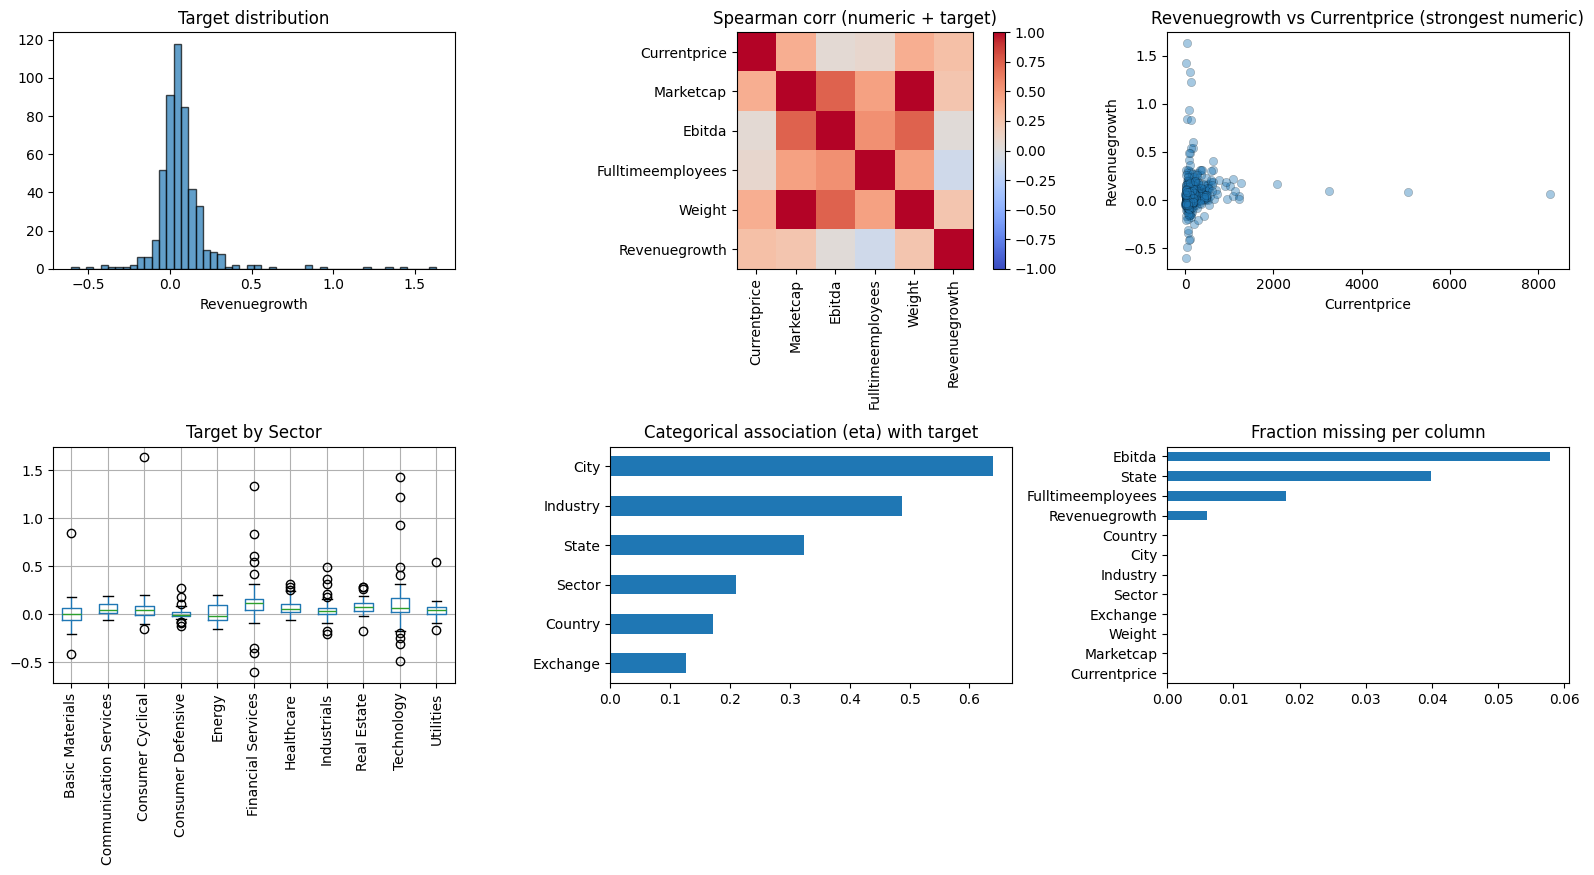

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

target = "Revenuegrowth"
num_cols = ["Currentprice", "Marketcap", "Ebitda", "Fulltimeemployees", "Weight"]
cat_cols = ["Exchange", "Sector", "Industry", "City", "State", "Country"]

d = df[[target] + num_cols + cat_cols].copy()

# ---- 1. target diagnostics ----
print("=== TARGET:", target, "===")
print(d[target].describe())
print("skew:", d[target].skew(), " kurtosis:", d[target].kurt())
print("missing:", d[target].isna().sum(), "of", len(d))

# ---- 2. numeric correlations (Pearson = linear, Spearman = monotonic) ----
print("\n=== NUMERIC CORRELATION WITH TARGET ===")
corr = pd.DataFrame({
    "pearson":  d[num_cols + [target]].corr(method="pearson")[target],
    "spearman": d[num_cols + [target]].corr(method="spearman")[target],
}).drop(index=target)
print(corr.sort_values("spearman", key=abs, ascending=False))

# ---- 3. categorical relationship: correlation ratio (eta) ----
# eta^2 = between-group variance / total variance; 0 = no relationship, 1 = perfect
def correlation_ratio(cats, values):
    m = values.notna() & cats.notna()
    cats, values = cats[m], values[m]
    grand = values.mean()
    ss_between = sum(len(g) * (g.mean() - grand) ** 2 for _, g in values.groupby(cats))
    ss_total = ((values - grand) ** 2).sum()
    return np.sqrt(ss_between / ss_total) if ss_total > 0 else np.nan

print("\n=== CATEGORICAL ASSOCIATION WITH TARGET (eta) ===")
eta = {c: correlation_ratio(d[c], d[target]) for c in cat_cols}
print(pd.Series(eta).sort_values(ascending=False))

# ---- 4. which sectors grow fastest? (sanity / interpretability) ----
print("\n=== MEAN TARGET BY SECTOR ===")
print(d.groupby("Sector")[target].agg(["mean", "median", "count"])
        .sort_values("median", ascending=False))

# ---- 5. visuals ----
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# target distribution
axes[0, 0].hist(d[target].dropna(), bins=50, edgecolor="k", alpha=0.7)
axes[0, 0].set_title("Target distribution"); axes[0, 0].set_xlabel(target)

# full numeric correlation heatmap (incl. target)
cm = d[num_cols + [target]].corr(method="spearman")
im = axes[0, 1].imshow(cm, cmap="coolwarm", vmin=-1, vmax=1)
axes[0, 1].set_xticks(range(len(cm))); axes[0, 1].set_xticklabels(cm.columns, rotation=90)
axes[0, 1].set_yticks(range(len(cm))); axes[0, 1].set_yticklabels(cm.columns)
axes[0, 1].set_title("Spearman corr (numeric + target)")
fig.colorbar(im, ax=axes[0, 1], fraction=0.046)

# strongest numeric feature vs target (scatter)
best = corr["spearman"].abs().idxmax()
axes[0, 2].scatter(d[best], d[target], alpha=0.4, edgecolor="k", linewidth=0.3)
axes[0, 2].set_xlabel(best); axes[0, 2].set_ylabel(target)
axes[0, 2].set_title(f"{target} vs {best} (strongest numeric)")

# target by sector (boxplot)
order = d.groupby("Sector")[target].median().sort_values().index
d.boxplot(column=target, by="Sector", ax=axes[1, 0], rot=90)
axes[1, 0].set_title("Target by Sector"); axes[1, 0].set_xlabel("")
plt.suptitle("")  # kill the auto title boxplot adds

# eta bar chart
pd.Series(eta).sort_values().plot.barh(ax=axes[1, 1])
axes[1, 1].set_title("Categorical association (eta) with target")

# missingness per column
(d.isna().mean().sort_values()
   .plot.barh(ax=axes[1, 2]))
axes[1, 2].set_title("Fraction missing per column")

plt.tight_layout()
plt.show()

In [27]:
print(df["Revenuegrowth"].sort_values(ascending=False).head(10))   # see the tail
q99 = df["Revenuegrowth"].quantile(0.99)
print("rows above 99th pct:", (df["Revenuegrowth"] > q99).sum())

307    1.632
384    1.430
223    1.334
1      1.224
96     0.933
215    0.847
341    0.833
216    0.605
37     0.541
196    0.539
Name: Revenuegrowth, dtype: float64
rows above 99th pct: 5


In [28]:
def correlation_ratio(cats, values):
    m = values.notna() & cats.notna()
    cats, values = cats[m], values[m]
    grand = values.mean()
    ss_between = sum(len(g) * (g.mean() - grand) ** 2 for _, g in values.groupby(cats))
    ss_total = ((values - grand) ** 2).sum()
    return np.sqrt(ss_between / ss_total) if ss_total > 0 else np.nan

for c in ["City", "Industry", "State"]:
    counts = df[c].value_counts()
    for thr in (1, 5, 10):
        big = counts[counts >= thr].index
        sub = df[df[c].isin(big)]
        eta = correlation_ratio(sub[c], sub["Revenuegrowth"])
        print(f"{c:9s} thr>={thr:2d}: {len(big):3d} groups, "
              f"{len(sub):3d} rows, eta = {eta:.3f}")

City      thr>= 1: 235 groups, 502 rows, eta = 0.639
City      thr>= 5:  20 groups, 189 rows, eta = 0.372
City      thr>=10:   5 groups,  98 rows, eta = 0.378
Industry  thr>= 1: 114 groups, 502 rows, eta = 0.488
Industry  thr>= 5:  39 groups, 334 rows, eta = 0.413
Industry  thr>=10:  11 groups, 147 rows, eta = 0.312
State     thr>= 1:  41 groups, 482 rows, eta = 0.323
State     thr>= 5:  23 groups, 444 rows, eta = 0.249
State     thr>=10:  16 groups, 390 rows, eta = 0.232


In [29]:
import numpy as np
df["rg_slog"] = np.sign(df["Revenuegrowth"]) * np.log1p(df["Revenuegrowth"].abs())
print("skew:", df["Revenuegrowth"].skew().round(2), "->", df["rg_slog"].skew().round(2))

for c in ["Industry", "City"]:
    counts = df[c].value_counts()
    big = counts[counts >= 5].index
    sub = df[df[c].isin(big)]
    print(f"{c} eta on slog target (thr>=5): "
          f"{correlation_ratio(sub[c], sub['rg_slog']):.3f}")

skew: 3.82 -> 2.11
Industry eta on slog target (thr>=5): 0.436
City eta on slog target (thr>=5): 0.384


In [25]:
import numpy as np
from sklearn.metrics import r2_score

baseline_pred = np.full_like(y_test, y_train.mean(), dtype=float)
print("Baseline R2 (predict mean):", r2_score(y_test, baseline_pred))   # ~0 by construction
print("Model R2:", reg.score(X_test, y_test))

Baseline R2 (predict mean): -0.05484067552681138
Model R2: -0.029719826214125167
